In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend

ImportError: cannot import name '_spropack' from 'scipy.sparse.linalg._propack' (/Applications/anaconda3/lib/python3.12/site-packages/scipy/sparse/linalg/_propack.cpython-312-darwin.so)

In [2]:
AWMD_df = pd.read_excel('AWMD_Mar2026.xlsx', sheet_name=2)

In [3]:
AWMD_df = AWMD_df.set_index(AWMD_df['date']).drop("date", axis=1)

# Output and inflation

In [4]:
# output
Y = AWMD_df["YER"][:-1]

t = np.arange(len(Y))

X = np.column_stack([np.ones(len(Y)), t])
beta = np.linalg.lstsq(X, Y, rcond=None)[0]

trend = X @ beta

Y_dev = (Y-trend)/trend

# inflation
P = AWMD_df["YED"]

pi = P.pct_change(periods=4)

/var/folders/33/xqtwrk8s3ws6yhnm9qx48q2m0000gn/T/ipykernel_10548/4209610064.py:16: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  pi = P.pct_change(periods=4)


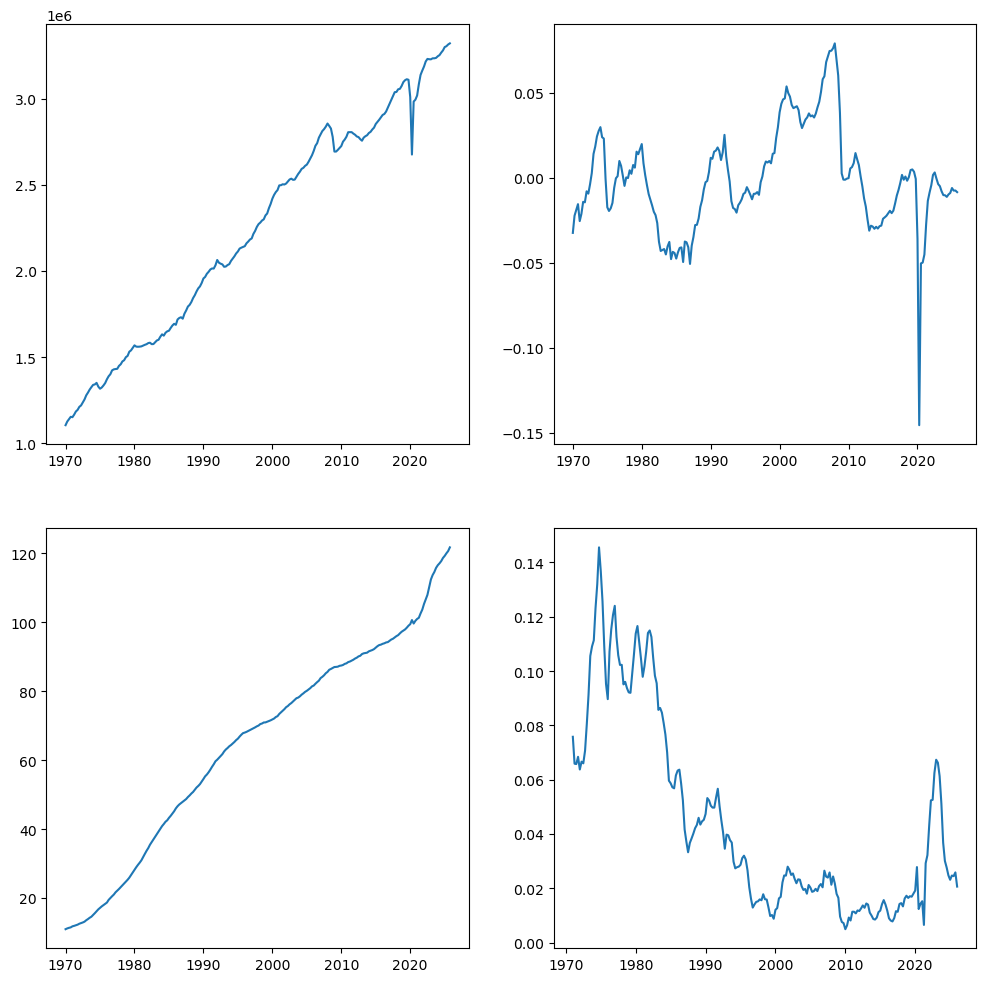

In [5]:
f, ax = plt.subplots(2,2, figsize=(12,12))

ax[0,0].plot(Y)
ax[0,1].plot(Y_dev)

ax[1,0].plot(P)
ax[1,1].plot(pi)

# Short and long Interest Rate

In [6]:
i = AWMD_df['STN']
i_l = AWMD_df["LTN"]

ZLB = 0.00

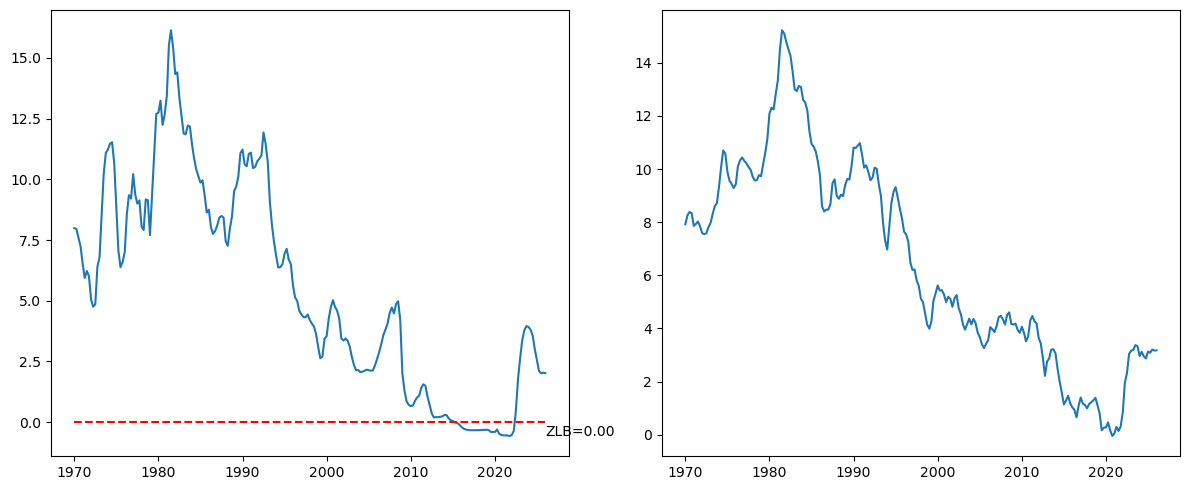

In [7]:
f, ax = plt.subplots(1,2,figsize=(12,5))

ax[0].plot(i)
ax[0].hlines(ZLB, xmin=i.index.min(), xmax=i.index.max(), color='red', ls = '--')
ax[0].text(i.index.max(), i.min(), f'ZLB={ZLB:.2f}')

ax[1].plot(i_l)

f.tight_layout()

In [8]:
print(f'{(i < ZLB).sum()} observations at ZLB:\n')
print(i[i <= 0].index)

29 observations at ZLB:

DatetimeIndex(['2015-04-01', '2015-07-01', '2015-10-01', '2016-01-01',
               '2016-04-01', '2016-07-01', '2016-10-01', '2017-01-01',
               '2017-04-01', '2017-07-01', '2017-10-01', '2018-01-01',
               '2018-04-01', '2018-07-01', '2018-10-01', '2019-01-01',
               '2019-04-01', '2019-07-01', '2019-10-01', '2020-01-01',
               '2020-04-01', '2020-07-01', '2020-10-01', '2021-01-01',
               '2021-04-01', '2021-07-01', '2021-10-01', '2022-01-01',
               '2022-04-01'],
              dtype='datetime64[ns]', name='date', freq=None)


# Empirical Relevance of the ZLB

In [9]:
ZLB = 0

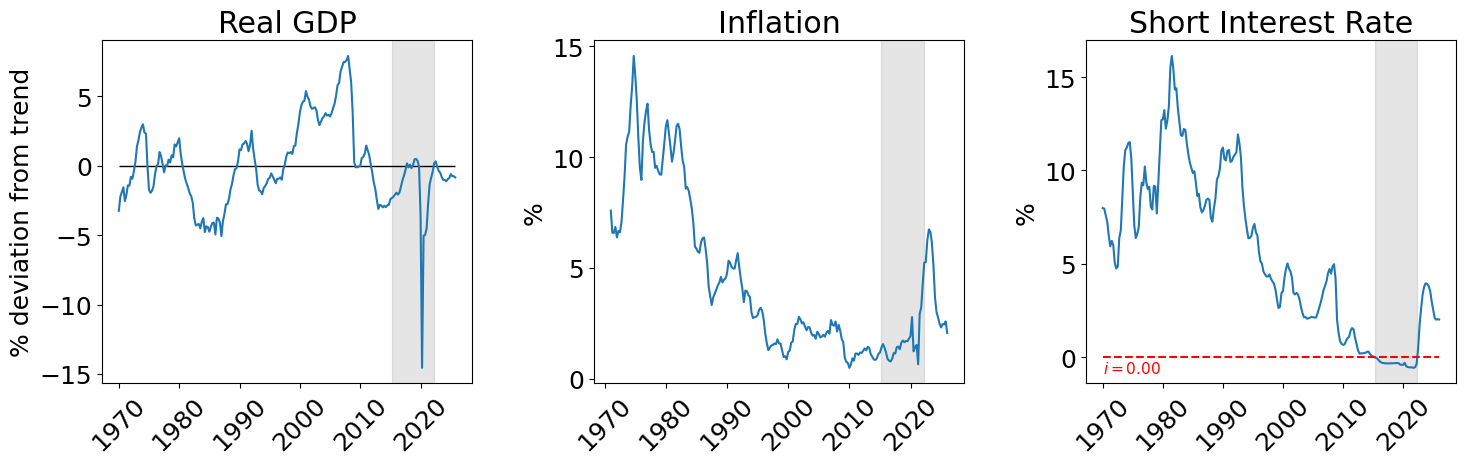

In [10]:
plt.rcParams.update({'font.size': 18})

f, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].hlines(0.0, xmin=Y_dev.index.min(), xmax=Y_dev.index.max(), color='black', ls='-', lw=1)
ax[0].plot(100*Y_dev)
ax[0].set_title('Real GDP')
ax[0].set_ylabel('% deviation from trend')

ax[1].plot(100*pi)
ax[1].set_title('Inflation')
ax[1].set_ylabel('%')

ax[2].plot(i)
ax[2].set_title('Short Interest Rate')
ax[2].set_ylabel('%')
ax[2].hlines(ZLB, xmin=i.index.min(), xmax=i.index.max(), color='red', ls = '--')
ax[2].text(i.index.min(), i.min()-0.3, f'$i=${ZLB:.2f}', color='red', fontsize=11)

mask = i < 0.0

for a in ax:
    a.tick_params(axis='x', rotation=45)

for j in range(3): 
    ax[j].fill_between(i.index, ax[j].get_ylim()[0], ax[j].get_ylim()[1],
                    where=mask, color='grey', alpha=0.2, transform=ax[j].get_xaxis_transform())

f.tight_layout()

f.savefig('Figure1.png')

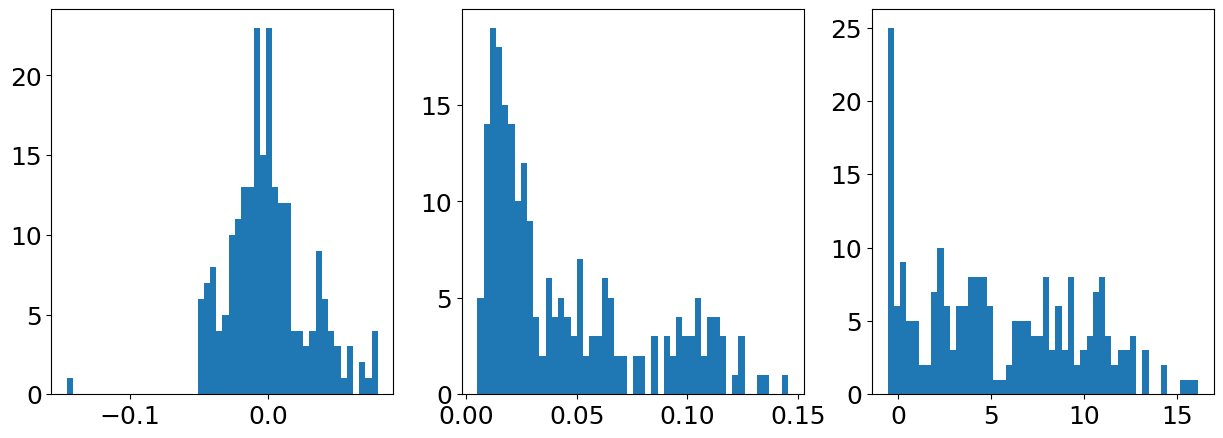

In [ ]:
f, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].hist(Y_dev, bins=50)
ax[1].hist(pi, bins=50)
ax[2].hist(i, bins=50);

In [53]:
print(f'\t\tmean\t\tstd\t\tautocorr\t\tmin\t\tmax')
print(f'Y_dev:\t\t-\t\t{np.std(Y_dev):.4f}\t\t{Y_dev.autocorr(lag=1):.4f}\t\t\t{np.min(Y_dev):.4f}\t\t{np.max(Y_dev):.4f}')
print(f'pi:\t\t{np.mean(pi):.4f}\t\t{np.std(pi):.4f}\t\t{pi.autocorr(lag=1):.4f}\t\t\t{np.min(pi):.4f}\t\t{np.max(pi):.4f}')
print(f'i:\t\t{np.mean(i/100):.4f}\t\t{np.std(i/100):.4f}\t\t\t\t\t{np.min(i/100):.4f}\t\t{np.max(i/100):.4f}')

		mean		std		autocorr		min		max
Y_dev:		-		0.0296		0.9227			-0.1456		0.0792
pi:		0.0445		0.0356		0.9895			0.0050		0.1456
i:		0.0543		0.0432					-0.0057		0.1613


# Calibration of Taylor Rule: MP-shock regression

In [ ]:
HICP = AWMD_df["HICP"]
oil_prices = AWMD_df["POILU"]
u = AWMD_df["URX"]
Exports = AWMD_df["XTR"][:-1]
Imports = AWMD_df["MTR"][:-1]

pi_c = HICP.pct_change(periods=4)
pi_oil = oil_prices.pct_change(periods=4)

Exports_dev = detrend(np.log(Exports)) #(Exports-detrend(Exports))/detrend(Exports)
Imports_dev = detrend(np.log(Imports)) #(Imports-detrend(Imports))/detrend(Imports)

/var/folders/33/xqtwrk8s3ws6yhnm9qx48q2m0000gn/T/ipykernel_9176/1127747214.py:7: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  pi_c = HICP.pct_change(periods=4)


In [ ]:
Y_dev_ = Y_dev[4:] # remove first 4 observations to make compatible with pi
pi_ = pi[4:-1] # first 4 obs are nans
i_lag_ = i[3:-2]/100
pi_c_ = pi_c[4:-1]
pi_oil_ = pi_oil[4:-1]
u_ = u[4:-1]

E_dev = Exports_dev[4:]
I_dev = Imports_dev[4:]
ts = np.arange(len(Y_dev_))

X = np.stack([np.ones(len(Y_dev_)), ts, Y_dev_, (pi_-0.02), (pi_c_-0.02), (pi_oil_), (u_), (E_dev), (I_dev)], axis=-1) # (pi_c_-0.02), pi_oil_, u_, E_dev, I_dev

y = np.asarray(i[4:-1]/100)[:, None]

In [ ]:
y = np.asarray(i[4:-1]/100)[:, None]

phis = (np.linalg.inv(X.T @ X) @ X.T)@y

nat_i = phis[0]

i_pred = X @ phis #nat_i + rho_i*i_lag_ + phi_y*Y_dev_ + phi_pi*(pi_-0.02)

i_error = y - i_pred

In [ ]:
i_error_reg = i_error[1:]
i_error_lag_reg = i_error[:-1]

# i_error_reg = np.asarray(i_error_reg)[:, None]
# i_error_lag_reg = np.asarray(i_error_lag_reg)[:, None]

rho_u = np.linalg.inv(i_error_lag_reg.T @ i_error_lag_reg) @ i_error_lag_reg.T @ i_error_reg

eps_u = i_error_reg - rho_u*i_error_lag_reg

sigma_eps_u = np.std(eps_u)

sigma_u = sigma_eps_u/np.sqrt(1-rho_u**2)

In [ ]:
print(f'AR(1)-regression:\trho_u = {rho_u[0,0]}\tsigma_eps_u = {sigma_eps_u}\tsigma_u = {sigma_u[0,0]}')

AR(1)-regression:	rho_u = 0.8753056797771661	sigma_eps_u = 0.008237880330892034	sigma_u = 0.017035547992014472


In [ ]:
print(f'beta = {(1/(1+nat_i))[0]}')

beta = 1.0022156950520273


# Productivity Regression

In [ ]:
Gamma = AWMD_df["LPROD_EMP"]
Gamma = Gamma[:-1] # last value is nan

# log transform
ln_Gamma = np.log(Gamma)

# compute trend
t = np.arange(len(ln_Gamma))
coeffs = np.polyfit(t, ln_Gamma, 2)
trend_quadratic = np.polyval(coeffs, t)

# subtract trend
ln_Gamma_cycle = ln_Gamma - trend_quadratic

In [ ]:
# drop first element in y-variable and last element in x-variable
ln_Gamma_reg = ln_Gamma_cycle[1:]
ln_Gamma_lag_reg = ln_Gamma_cycle[:-1]

# convert to array and add dim
ln_Gamma_reg = np.asarray(ln_Gamma_reg)[:, None]
ln_Gamma_lag_reg = np.asarray(ln_Gamma_lag_reg)[:, None]

# ols
rho_gamma = np.linalg.inv(ln_Gamma_lag_reg.T @ ln_Gamma_lag_reg) @ ln_Gamma_lag_reg.T @ ln_Gamma_reg

# error
eps_gamma = ln_Gamma_reg - rho_gamma*ln_Gamma_lag_reg

# std
sigma_eps_gamma = np.std(eps_gamma)
sigma_gamma = sigma_eps_gamma/np.sqrt(1-rho_gamma**2)

print(f'AR(1)-regression:\trho_Gamma = {rho_gamma[0,0]}\tsigma_eps_Gamma = {sigma_eps_gamma}\tsigma_gamma = {sigma_gamma[0,0]}')

AR(1)-regression:	rho_Gamma = 0.7558959755624528	sigma_eps_Gamma = 0.009681786136508547	sigma_gamma = 0.014788312649016564


<>:28: SyntaxWarning: invalid escape sequence '\h'
<>:28: SyntaxWarning: invalid escape sequence '\h'
/var/folders/33/xqtwrk8s3ws6yhnm9qx48q2m0000gn/T/ipykernel_9176/3002833388.py:28: SyntaxWarning: invalid escape sequence '\h'
  ax[2].set_title('$\hat{\epsilon}^{\Gamma}$ and fitted normal pdf')


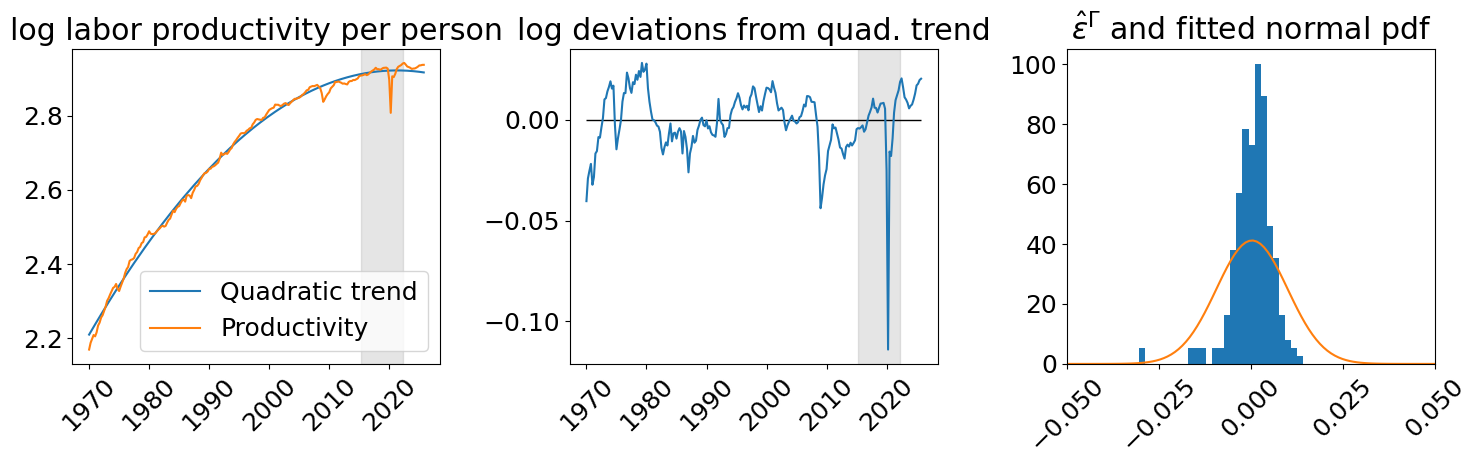

In [ ]:
f, ax = plt.subplots(1,3,figsize=(15,5))

ax[0].plot(ln_Gamma.index, trend_quadratic, label='Quadratic trend')
ax[0].plot(ln_Gamma, label='Productivity')
ax[0].set_title('log labor productivity per person')

ax[1].hlines(0.0, xmin=ln_Gamma.index.min(), xmax=ln_Gamma.index.max(), color='black', ls='-', lw=1)
ax[1].plot(ln_Gamma_cycle)
ax[1].set_title('log deviations from quad. trend')

for a in ax:
    a.tick_params(axis='x', rotation=45)

i_ = i[:-1]
common_index = ln_Gamma.index.intersection(i_.index)

mask = (i_.loc[common_index] < 0.0)

for j in range(2): 
    ax[j].fill_between(i_.index, 0, 1,
                    where=mask, color='grey', alpha=0.2, transform=ax[j].get_xaxis_transform())

ax[0].legend()

ax[2].hist(eps_gamma, bins=100, density=True)
ax[2].plot(np.linspace(-0.05, 0.05, 100), s.norm.pdf(np.linspace(-0.05, 0.05, 100), loc=np.mean(eps_gamma), scale=sigma_eps_gamma))
ax[2].set_xlim([-0.05, 0.05])
ax[2].set_title('$\hat{\epsilon}^{\Gamma}$ and fitted normal pdf')

f.tight_layout()

f.savefig('ln_Gamma_AR1.png')

# Regression plots

<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\h'
/var/folders/33/xqtwrk8s3ws6yhnm9qx48q2m0000gn/T/ipykernel_9176/78326659.py:7: SyntaxWarning: invalid escape sequence '\h'
  ax[0,0].plot(i[4:-1].index, i_pred*100, label='$\hat{i}_t$')
/var/folders/33/xqtwrk8s3ws6yhnm9qx48q2m0000gn/T/ipykernel_9176/78326659.py:10: SyntaxWarning: invalid escape sequence '\h'
  ax[0,1].plot(i[4:-1].index, (i_error*100)[:, 0], label='$i_t-\hat{i}_t$')
/var/folders/33/xqtwrk8s3ws6yhnm9qx48q2m0000gn/T/ipykernel_9176/78326659.py:20: SyntaxWarning: invalid esc

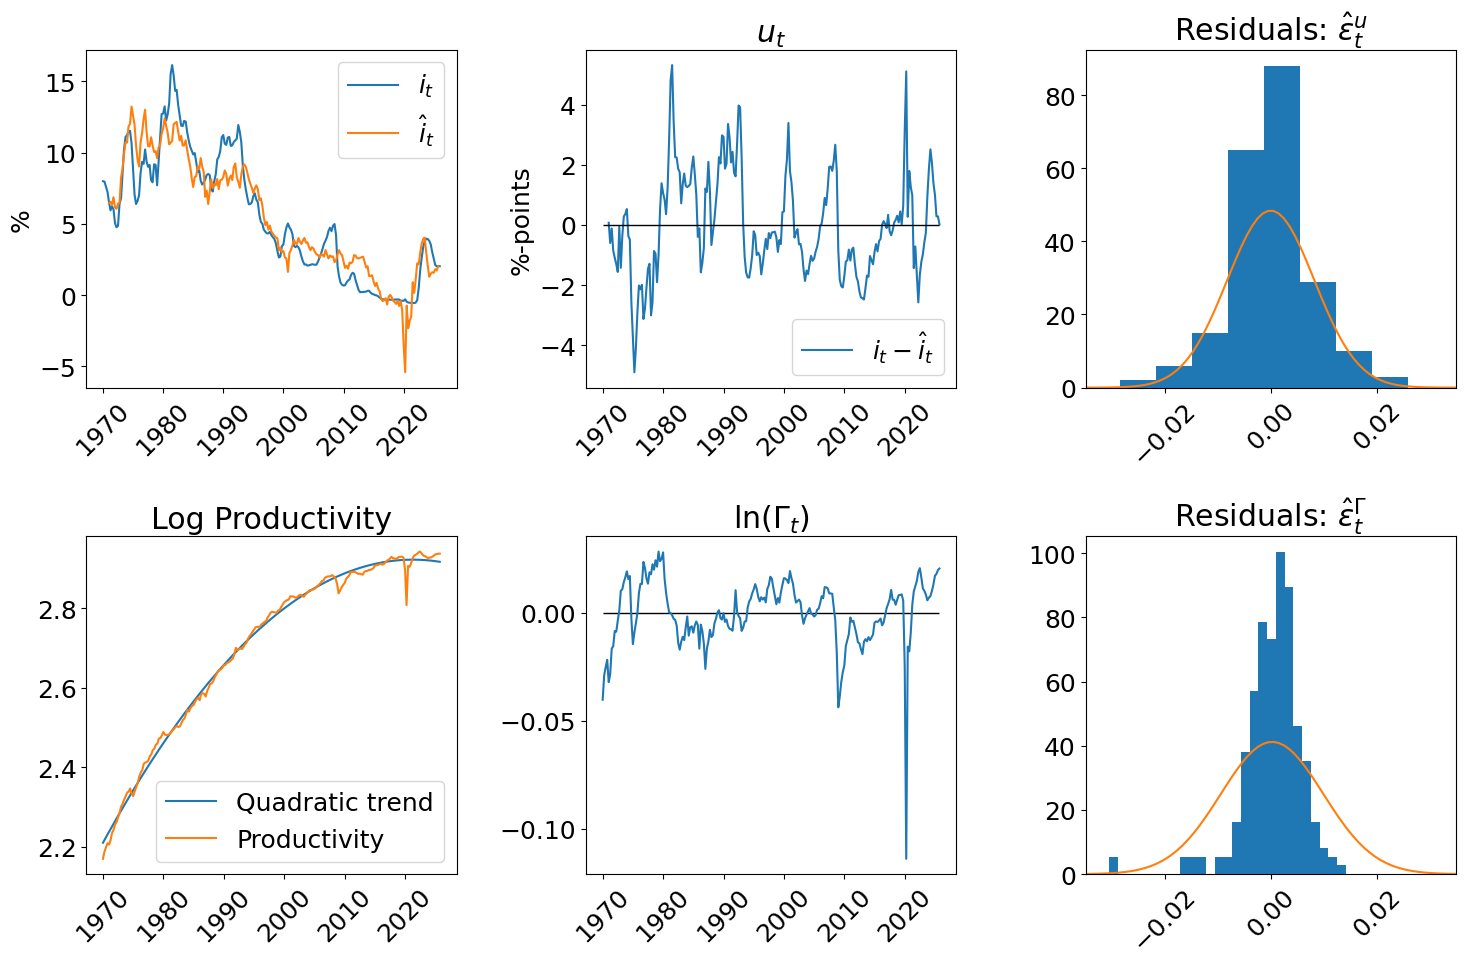

In [ ]:
f, ax = plt.subplots(2,3, figsize=(15,10))

x = np.linspace(-0.05, 0.05, 100)

# MP-shock
ax[0,0].plot(i, label='$i_t$')
ax[0,0].plot(i[4:-1].index, i_pred*100, label='$\hat{i}_t$')
ax[0,0].set_ylabel('%')

ax[0,1].plot(i[4:-1].index, (i_error*100)[:, 0], label='$i_t-\hat{i}_t$')
ax[0,1].hlines(0.0, xmin=i[:-1].index.min(), xmax=i[:-1].index.max(), color='black', ls='-', lw=1)
ax[0,1].set_title('$u_t$')
ax[0,1].set_ylabel('%-points')

ax[0,2].hist(eps_u)
ax[0,2].plot(x, s.norm.pdf(x,
                           loc=np.mean(eps_u), scale=sigma_eps_u),
                           label=fr'$\mathcal{{N}}({np.mean(eps_u):.3f}, {sigma_eps_u:.3f})$')
ax[0,2].set_xlim([-0.035, 0.035])
ax[0,2].set_title('Residuals: $\hat{\epsilon}^{u}_t$')

# productivity-shock
ax[1,0].plot(ln_Gamma.index, trend_quadratic, label='Quadratic trend')
ax[1,0].plot(ln_Gamma, label='Productivity')
ax[1,0].set_title('Log Productivity')

ax[1,1].hlines(0.0, xmin=ln_Gamma.index.min(), xmax=ln_Gamma.index.max(), color='black', ls='-', lw=1)
ax[1,1].plot(ln_Gamma_cycle)
ax[1,1].set_title('$\ln(\Gamma_t)$')

ax[1,2].hist(eps_gamma, bins=100, density=True)
ax[1,2].plot(
    x,
    s.norm.pdf(x, loc=np.mean(eps_gamma), scale=sigma_eps_gamma),
    label=fr'$\mathcal{{N}}({np.mean(eps_gamma):.3f}, {sigma_eps_gamma:.3f})$'
)
ax[1,2].set_xlim([-0.035, 0.035])
ax[1,2].set_title('Residuals: $\hat{\epsilon}^{\Gamma}_t$')


for j in range(2):
    for k in range(3):
        ax[j,k].tick_params(axis='x', rotation=45)

for j in range(2): 
    for k in range(2):
        # ax[j,k].fill_between(i.index, 0, 1,
        #                 where=mask, color='grey', alpha=0.2, transform=ax[j,k].get_xaxis_transform())
        
        if not ((j==1) and (k==1)):
            ax[j,k].legend()

f.tight_layout();

f.savefig('Gamma_Taylor_Regressions.png')